# Steerling-8B: Chunk-to-Concept Attribution

Concept attribution explains **why** the model generated each token, in terms of concepts. Steerling captures this **during generation itself**: each
token's attribution comes from the exact forward pass that committed it, using the
partially-masked context the model actually saw — which is what makes it faithful by design.

For each predicted token $y_t$, Steerling's concept heads decompose the output logit
into per-concept contributions:

$$C(c_i, y_t) = \sigma(\text{logit}_i) \cdot (e_i \cdot W_{y_t})$$

Contributions sum to the token's logit, up to a residual $\varepsilon_t$ not explained
by any concept (we verify this numerically in Section 4).

Consecutive tokens are grouped into **chunks**. To score a chunk, we normalize each
position's contributions (so every token votes equally) then average:

$$\text{chunk\_score}(i) = \frac{1}{T} \sum_{t \in \text{chunk}} \frac{C(c_i, y_t)}{\sum_j |C(c_j, y_t)| + |\varepsilon_t|}$$

**Requirements:** Interpretable Steerling model, GPU with >= 18 GB VRAM

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from transformers import AutoModel, AutoTokenizer
from steerling import SteerlingGenerator, GenerationConfig
from steerling.attribution.concept_attribution import (
    FaithfulConceptAttributor, find_chunk_boundaries, chunk_attribution,
)

PURPLE = "#675BF2"
PURPLE_LIGHT = "#ceb4fe"
COLOR_MAP = {"known": PURPLE, "discovered": PURPLE_LIGHT}

## 1. Load Model & Concept Labels

In [9]:
model_id = "guidelabs/steerling-8b"

model = AutoModel.from_pretrained(model_id, trust_remote_code=True, dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
generator = SteerlingGenerator.from_model(model, tokenizer, device="cuda")

print(generator)
print(f"Interpretable: {generator.is_interpretable}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

SteerlingGenerator(
  params=8,391,778,304,
  device=cuda,
  interpretable=True,
  diff_block_size=64
)
Interpretable: True


In [10]:
def find_repo_root(marker="pyproject.toml"):
    for p in [Path().resolve(), *Path().resolve().parents]:
        if (p / marker).exists():
            return p
    raise FileNotFoundError(f"Could not find repo root (looking for {marker})")

REPO_ROOT = find_repo_root()
concepts_path = REPO_ROOT / "assets" / "concepts" / "concept_labels.parquet"
if not concepts_path.exists():
    concepts_path = None
    print("No concept file found, using fallback labels")
else:
    print(f"Found concept labels at {concepts_path}")

Found concept labels at /fss/aya/home/steerling_public/assets/concepts/concept_labels.parquet


## 2. Create Attributor

The `FaithfulConceptAttributor` wraps the generator and captures attribution
during generation via a step callback.

In [ ]:
attributor = FaithfulConceptAttributor(
    generator,
    concepts_path=concepts_path,
)

## 3. Generate & Attribute

In [12]:
prompt = "AI technology will"
config = GenerationConfig(max_new_tokens=128, steps=128, seed=42)

gen_output, chunk_results = attributor.attribute(prompt, config)

print(f"Generated ({gen_output.generated_tokens} tokens):")
print(gen_output.text)

Generated (128 tokens):
 be able to analyze the tone and emotion of a person's voice, allowing for more personalized and natural interactions.

<|endofchunk|>Enhanced Language Understanding

With advancements in speech recognition and natural language processing, AI virtual assistants will be able to understand and respond to a wider range of user queries. This will enable virtual assistants to provide more accurate and relevant information, enhancing the overall user experience.

Improved Contextual Awareness

As AI technologies improve, they will become better at understanding the context of a conversation or situation. This will allow virtual assistants to provide more appropriate and helpful responses, taking into account the user's previous interactions and preferences.

<|endofchunk|>Real-Time Interaction




/fss/aya/home/steerling_public/steerling/attribution/concept_attribution.py:682: UserWarning: 3 of 131 positions were never committed. Their attributions will be zero.
  attr = accumulator.result()


## 4. Explore the Attribution

The attributor stores per-token concept contributions in `last_attribution`. Let's look at the
raw data before plotting.

In [ ]:
attr = attributor.last_attribution

print(f"Attributed positions:           {attr.known_contributions.shape[1]}")
print(f"Top-k known concepts per token: {attr.known_contributions.shape[-1]}")
print(f"Top-k discovered per token:     {attr.unk_contributions.shape[-1]}")

# Verify decomposition: contributions should sum to target logits
verification = attr.verify()
print(f"\nDecomposition check: max error = {verification.max_abs_error:.6f} (pass={verification.passed})")

In [14]:
# Top concepts for a single token position
pos = gen_output.prompt_tokens  # first generated token
token_str = generator.tokenizer.decode([gen_output.tokens[pos].item()])
print(f"Token at position {pos}: {token_str!r}\n")

# Show top-5 known concept contributions at this position
contribs = attr.known_contributions[0, pos]  # (k_known,)
indices = attr.known_indices[0, pos]
top_vals, top_idx = contribs.abs().topk(min(5, contribs.shape[0]))

for i in top_idx:
    cid = int(indices[i])
    label = attributor.labels.label(cid, "known")
    print(f"  {contribs[i]:+.4f}  {label}")

Token at position 3: ' be'

  +0.3373  Known: Automation Displacing Human Labor
  +0.2665  Known: Possibility and Epistemic Modality
  -0.2168  Known: Temporal sequence and timing
  +0.1493  Known: Legal and Policy Governance
  +0.1013  Known: Play (multilingual, multi-sense)


## 5. Chunk-Level Visualization

Each concept's contribution is its **fraction of total logit mass** averaged across the chunk.
Because contributions are normalized per token and then averaged, individual values are small
(typically < 2%) — what matters is the **relative ranking**, not the absolute numbers.

**Epsilon** is the percentage of logit mass not explained by any concept. Lower epsilon means
the concepts account for more of the model's prediction.

Known concepts in purple, discovered in light purple.

In [15]:
def plot_contributions(entries, title="Concept Contributions", eps_pct=0.0, top_k=20):
    """Horizontal bar chart of top concept contributions."""
    display = sorted(entries, key=lambda e: e["contribution"], reverse=True)[:top_k]

    labels = [e["label"] for e in display]
    values = [e["contribution"] for e in display]
    colors = [COLOR_MAP[e["type"]] for e in display]

    fig, ax = plt.subplots(figsize=(10, max(3, len(labels) * 0.35)))
    y = np.arange(len(labels))
    ax.barh(y, values, color=colors)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Fraction of total |logit| mass")
    ax.set_title(f"{title}  |  epsilon = {eps_pct:.1f}%", fontsize=11)
    ax.legend(
        handles=[Patch(fc=COLOR_MAP[t], label=t.title()) for t in ["known", "discovered"]],
        loc="lower right", fontsize=8,
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


=== Chunk [3, 25) | epsilon = 24.2% ===
  Text: " be able to analyze the tone and emotion of a person's voice, allowing for more personalized and nat"
  known         1.30%  Known: Legal and Policy Governance
  known         1.28%  Known: Digital Marketing and CRM
  known         1.05%  Known: How-to Instructional Steps
  known         0.90%  Known: Customization and Personalization
  known         0.84%  Known: Comparative Adjectives (-er forms)
  known         0.83%  Known: Mood, Attitude, and Vibe
  known         0.82%  Known: Letting, Allowing, Enabling
  known         0.81%  Known: Artificial Intelligence and Machine Learning
  discovered    0.77%  Discovered: States of Existence and Occurrence
  discovered    0.76%  Discovered: Performance and Temporal Metrics


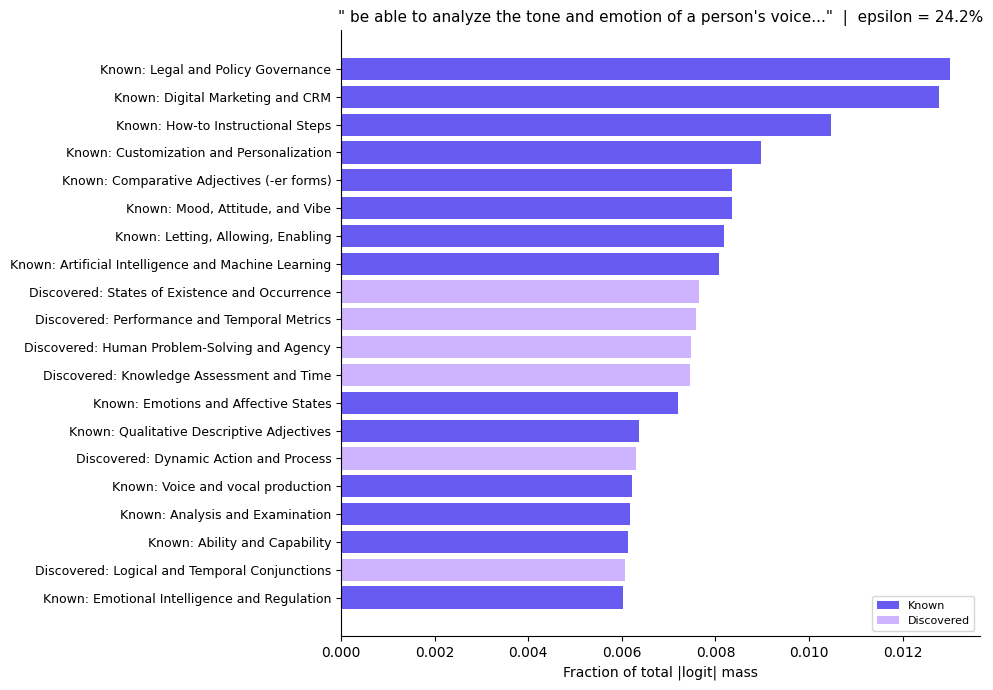


=== Chunk [26, 126) | epsilon = 19.1% ===
  Text: 'Enhanced Language Understanding\n\nWith advancements in speech recognition and natural language proces'
  known         1.97%  Known: Artificial Intelligence and Machine Learning
  known         1.93%  Known: Legal and Policy Governance
  known         1.36%  Known: Assistive Augmentation Technologies
  known         1.34%  Known: Chatbots and Conversational Agents
  known         0.99%  Known: 'il'/'ill' Subword Pattern
  known         0.97%  Known: Enterprise Digital Transformation Jargon
  known         0.91%  Known: How-to Instructional Steps
  known         0.91%  Known: Speech and Voice Audio
  known         0.86%  Known: Marketing Buzzword Prose
  known         0.79%  Known: User and Interface


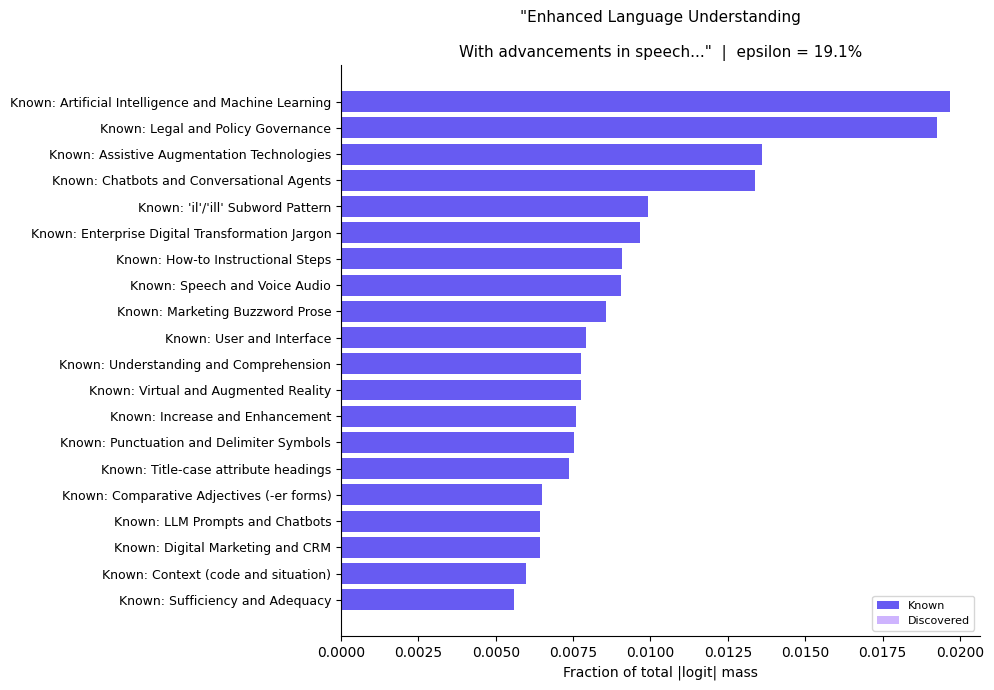


=== Chunk [127, 131) | epsilon = 17.7% ===
  Text: 'Real-Time Interaction\n\n'
  known         7.36%  Known: Title-case attribute headings
  known         6.13%  Known: Punctuation and Delimiter Symbols
  known         4.41%  Known: Time and temporal references
  known         3.93%  Known: Technical Documentation Features
  known         3.27%  Known: Inter- prefix and interaction
  known         3.04%  Known: Capitalized Encyclopedic Index Terms
  known         2.75%  Known: Hyphen-Separated Slug Tokens
  known         1.77%  Known: Marketing Buzzword Prose
  known         1.68%  Known: Enterprise Digital Transformation Jargon
  known         1.66%  Known: Adjectival -ic/-ical Suffixes


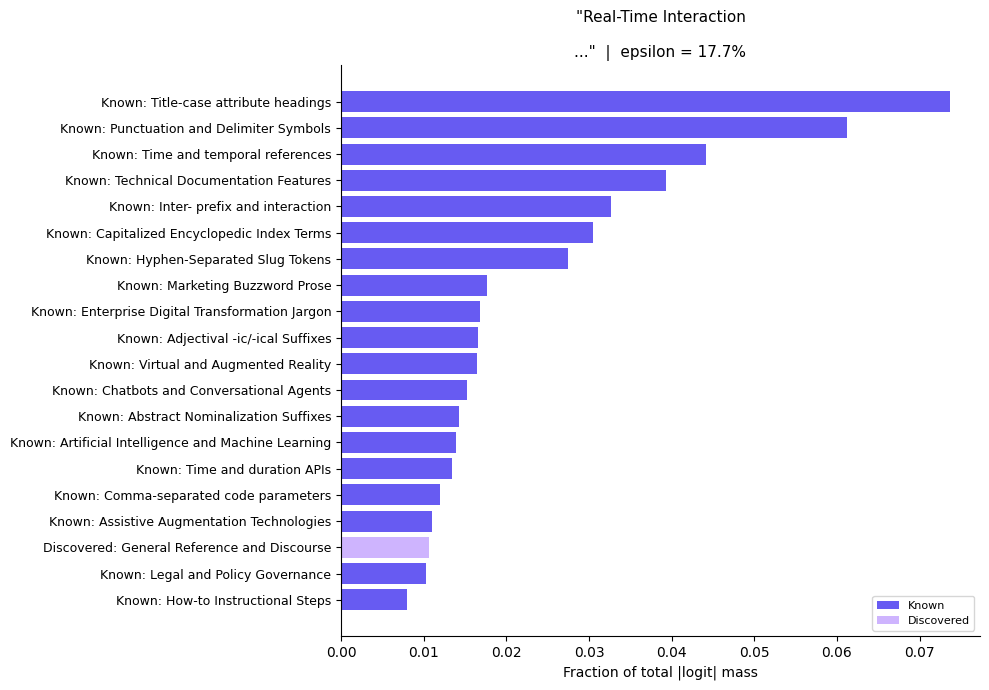

In [16]:
tokens = gen_output.tokens
prompt_len = gen_output.prompt_tokens
eoc_id = getattr(generator.tokenizer, "endofchunk_token_id", None)
eot_id = getattr(generator.tokenizer, "eot_id", None)
stop = [eot_id] if eot_id is not None else None

chunks = find_chunk_boundaries(
    tokens.tolist(),
    eoc_id=eoc_id if eoc_id is not None else -1,
    start_index=prompt_len,
    stop_ids=stop,
    include_final_chunk=True,
)
attr = attributor.last_attribution

for s, e in chunks:
    entries, eps_pct = chunk_attribution(
        attr, s, e, batch=0,
        concept_labels=attributor.labels,
        num_known_concepts=attributor._num_known_concepts,
    )
    text_preview = generator.tokenizer.decode(tokens[s:e].tolist(), skip_special_tokens=True)[:100]

    print(f"\n=== Chunk [{s}, {e}) | epsilon = {eps_pct:.1f}% ===")
    print(f"  Text: {text_preview!r}")
    top = sorted(entries, key=lambda e: e["contribution"], reverse=True)[:10]
    for entry in top:
        print(f"  {entry['type']:<12s} {entry['contribution']:6.2%}  {entry['label']}")

    plot_contributions(
        entries,
        title=f'"{text_preview[:60]}..."',
        eps_pct=eps_pct,
        top_k=20,
    )